In [3]:
from collections import defaultdict

import polars as pl

import social_groups.polars_columns as plc
import social_groups.polars_values as plv
from social_groups.analysis.defs.notebooks.definitions import register_materialization
from social_groups.analysis.polars_transformations.apply_parsing_and_group_decision import (
    apply_parsing_and_group_decision,
)
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
)
from social_groups.reporting.parsing import (
    AnswerComparer,
    AnswerOptions,
    AnswerParser,
)

%load_ext autoreload
%autoreload 2

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:398: BetaWarning: Class `Manager` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  MANAGER_FOR_NOTEBOOK_INSTANCE = Manager()
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:120: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:125: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterth

In [4]:
triple_underscore_handling = "wrong"

parser = AnswerParser(AnswerOptions.letters_A_to_J)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_J, triple_underscore_handling=triple_underscore_handling
)

In [5]:
from social_groups.analysis.definitions import defs

thinking_frame: pl.DataFrame = defs().load_asset_value("thinking_mad")

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_config/pythonic_config/typing_utils.py:111: UserWarning: Field name "extension" in "PolarsParquetIOManager" shadows an attribute in parent "BasePolarsUPathIOManager"
  return super().__new__(cls, name, bases, namespaces, **kwargs)
2026-03-10 12:04:25 +0800 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/thinking_mad.parquet using PolarsParquetIOManager...


In [6]:
thinking_frame.head()

shape: (5, 18)
┌───────┬────────┬────────────┬────────────┬───┬────────────┬────────────┬────────────┬────────────┐
│ id    ┆ run_id ┆ question_i ┆ phoenix_sp ┆ … ┆ question   ┆ answer_str ┆ thinking_m ┆ group_cons │
│ ---   ┆ ---    ┆ d          ┆ an_id      ┆   ┆ ---        ┆ ing        ┆ odels      ┆ tellation  │
│ i64   ┆ i64    ┆ ---        ┆ ---        ┆   ┆ str        ┆ ---        ┆ ---        ┆ ---        │
│       ┆        ┆ i64        ┆ str        ┆   ┆            ┆ str        ┆ str        ┆ str        │
╞═══════╪════════╪════════════╪════════════╪═══╪════════════╪════════════╪════════════╪════════════╡
│ 11340 ┆ 121    ┆ 25         ┆ 45942f7c45 ┆ … ┆ Q: What    ┆ J          ┆ H          ┆ MM         │
│       ┆        ┆            ┆ 3b81f3     ┆   ┆ stable     ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ isotope is ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ comm…      ┆            ┆            ┆            │
│ 11341 ┆ 121    ┆ 0          ┆ 52ca872339 ┆ … ┆ Q: What    ┆ B          ┆ H          ┆ MM         │
│       ┆        ┆            ┆ e4b0d9     ┆   ┆ will       ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ happen to  ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ the equ…   ┆            ┆            ┆            │
│ 11342 ┆ 121    ┆ 32         ┆ 8a1a264ccf ┆ … ┆ Q: In      ┆ C          ┆ H          ┆ MM         │
│       ┆        ┆            ┆ 2cda6c     ┆   ┆ building a ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ linear     ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ regres…    ┆            ┆            ┆            │
│ 11343 ┆ 121    ┆ 26         ┆ c2d224ef0a ┆ … ┆ Q: An      ┆ I          ┆ H          ┆ MM         │
│       ┆        ┆            ┆ 3056ff     ┆   ┆ electric   ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ dipole     ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ consisti…  ┆            ┆            ┆            │
│ 11344 ┆ 121    ┆ 31         ┆ 57a4af65ef ┆ … ┆ Q:  When   ┆ A          ┆ H          ┆ MM         │
│       ┆        ┆            ┆ 83e8f7     ┆   ┆ was the    ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ major      ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ shift b…   ┆            ┆            ┆            │
└───────┴────────┴────────────┴────────────┴───┴────────────┴────────────┴────────────┴────────────┘

In [7]:
main_results = (
    apply_parsing_and_group_decision(thinking_frame, parser, comparer, group_reply)
    .group_by([plc.group_constellation, plc.thinking_models])
    .agg(pl.mean(plc.is_correct).alias(plc.accuracy))
).sort(plc.accuracy, descending=True)
register_materialization("thinking_mad_evaluation_table", main_results, description="Different settings of thinking models in different group constellations using MAD and their respective accuracy.")
main_results

Skipping Materialization because in interactive mode.


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_core/execution/context_creation_job.py:276: RuntimeWarning: coroutine 'BaseEventLoop.shutdown_asyncgens' was never awaited
  pass


group_constellation,thinking_models,accuracy
str,str,f64
"""HHH""","""L""",0.76
"""HH""","""everyone""",0.76
"""HH""","""H""",0.76
"""HHM""","""nobody""",0.74
"""HHH""","""everyone""",0.73
…,…,…
"""LLL""","""H""",0.33
"""LLL""","""nobody""",0.31
"""LL""","""everyone""",0.31


In [8]:
thinking_data = main_results.pivot(
    plc.thinking_models, index=plc.group_constellation, values=plc.accuracy
).with_columns(
    (pl.col(plv.thinking_models.everyone) - pl.col(plv.thinking_models.nobody)).alias(
        "full thinking vs. no thinking"
    )
).sort("full thinking vs. no thinking", descending=True)

In [9]:
register_materialization("mad_evaluation_table_per_group_constellation_with_different_thinking_models", thinking_data, description="Different group constellations and their accuracies based on who in the group is allowed to think. It also shows the difference in allowing everyone or noone to think.")
thinking_data

Skipping Materialization because in interactive mode.


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_core/execution/context_creation_job.py:276: RuntimeWarning: coroutine 'BaseEventLoop.shutdown_asyncgens' was never awaited
  pass


group_constellation,L,everyone,H,nobody,full thinking vs. no thinking
str,f64,f64,f64,f64,f64
"""LLL""",0.34,0.41,0.33,0.31,0.1
"""LM""",0.45,0.52,0.45,0.44,0.08
"""HH""",0.7,0.76,0.76,0.68,0.08
"""LL""",0.34,0.31,0.28,0.25,0.06
"""MM""",0.58,0.61,0.47,0.55,0.06
…,…,…,…,…,…
"""HHM""",0.72,0.7,0.66,0.74,-0.04
"""HM""",0.65,0.61,0.59,0.65,-0.04
"""HHL""",0.61,0.65,0.66,0.7,-0.05


Skipping Materialization because in interactive mode.


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_core/execution/context_creation_job.py:276: RuntimeWarning: coroutine 'BaseEventLoop.shutdown_asyncgens' was never awaited
  pass


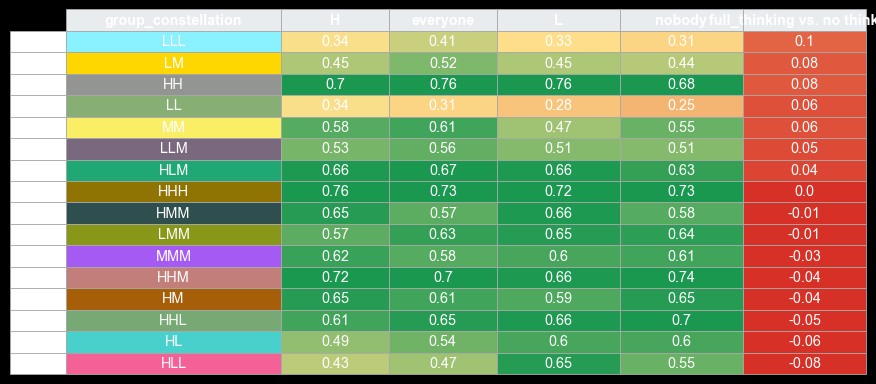

In [10]:
import random

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, get_named_colors_mapping

data = thinking_data.with_columns(pl.col("full thinking vs. no thinking").round(2)).to_numpy()

col_labels = [
    "group_constellation",
    "H",
    "everyone",
    "L",
    "nobody",
    "full_thinking vs. no thinking",
]
row_labels = [f"Run {i + 1}" for i in range(len(data))]

# ────────────────────────────────────────────────
# Color gradient: red → white → green for accuracy
# ────────────────────────────────────────────────

colors = ["#d73027", "#fee08b", "#1a9850"]  # red – light yellow – green
all_colors = list(get_named_colors_mapping().values())
cmap = LinearSegmentedColormap.from_list("acc", colors, N=256)


def acc_to_color(value):
    """Map accuracy [0,1] → color"""
    # Optional: clip just in case
    v = max(0.0, min(1.0, float(value)))
    return cmap(v)


# ────────────────────────────────────────────────
# Build 2D list of cell background colors
# ────────────────────────────────────────────────

category_colors = defaultdict(lambda: random.choice(all_colors))

cell_colors = []
for row in data:
    row_colors = []
    for j, val in enumerate(row):
        if j >= 1:  # accuracy column (0-based index 3)
            color = acc_to_color(val * 1.5)
        else:
            color = category_colors[val]
        row_colors.append(color)
    cell_colors.append(row_colors)

# ────────────────────────────────────────────────
# Create figure and table
# ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 4.2))  # adjust as needed
ax.axis("off")

table = ax.table(
    cellText=data,
    cellColours=cell_colors,
    rowLabels=row_labels,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
    colWidths=[0.28, 0.14, 0.14, 0.16, 0.16, 0.16],
)

table.auto_set_font_size(False)
table.set_fontsize(10.4)
table.scale(1.2, 1.6)  # horizontal / vertical stretch

# Optional: nicer grid
for (i, j), cell in table.get_celld().items():
    cell.set_edgecolor("#aaaaaa")
    cell.set_linewidth(0.6)
    # Make header row bold / different bg
    if i == 0:
        cell.set_facecolor("#e8ecef")
        cell.set_text_props(weight="bold")

# Optional title

plt.tight_layout()
register_materialization("thinking_mad_comparison_colored", fig, "Accuracies for different group constellations and different models allowed to think ")
plt.show()